# Task 12: Knowledge Distillation

## Objective

Implement a simplified Knowledge Distillation system where a smaller
student model learns from a larger teacher model.

This task demonstrates:

- Teacher model
- Student model
- Soft predictions
- Temperature
- Distillation loss
- Student training
- Knowledge transfer

Knowledge distillation allows a smaller model to learn useful knowledge
from a larger pretrained model.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("Libraries imported successfully!")

PyTorch version: 2.13.0+cpu
Libraries imported successfully!


## Step 1: Create a Dataset

We create a simple synthetic classification dataset.

The same dataset will be used to train the teacher and student models.

In [2]:
num_samples = 1000
input_size = 10
num_classes = 3

X = torch.randn(
    num_samples,
    input_size
)

y = torch.randint(
    0,
    num_classes,
    (num_samples,)
)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: torch.Size([1000, 10])
Target shape: torch.Size([1000])


## Step 2: Create the Teacher Model

The teacher model is larger and has more hidden units.

In a real application, the teacher would usually be a larger,
more powerful pretrained model.

In [3]:
class TeacherModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        return self.network(x)


teacher = TeacherModel()

print(teacher)

TeacherModel(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)


## Step 3: Train the Teacher Model

First, we train the larger teacher model.

The trained teacher will provide knowledge to the student model.

In [4]:
teacher_optimizer = optim.Adam(
    teacher.parameters(),
    lr=0.01
)

teacher_loss_history = []

for epoch in range(200):

    output = teacher(X)

    loss = F.cross_entropy(
        output,
        y
    )

    teacher_optimizer.zero_grad()

    loss.backward()

    teacher_optimizer.step()

    teacher_loss_history.append(
        loss.item()
    )

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {loss.item():.4f}"
        )

Epoch 50: Loss = 0.4863
Epoch 100: Loss = 0.0791
Epoch 150: Loss = 0.0181
Epoch 200: Loss = 0.0078


## Step 4: Evaluate Teacher

We check the teacher's classification accuracy before transferring
knowledge to the student.

In [5]:
with torch.no_grad():

    teacher_output = teacher(X)

    teacher_predictions = torch.argmax(
        teacher_output,
        dim=1
    )

teacher_accuracy = (
    teacher_predictions == y
).float().mean()

print(
    "Teacher Accuracy:",
    round(
        teacher_accuracy.item() * 100,
        2
    ),
    "%"
)

Teacher Accuracy: 100.0 %


## Step 5: Create the Student Model

The student model is intentionally smaller than the teacher.

The goal is for the student to achieve useful performance with fewer
parameters.

In [6]:
class StudentModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),

            nn.Linear(16, num_classes)
        )

    def forward(self, x):

        return self.network(x)


student = StudentModel()

print(student)

StudentModel(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=3, bias=True)
  )
)


## Step 6: Compare Model Sizes

We compare the number of parameters in the teacher and student models.

In [7]:
teacher_parameters = sum(
    p.numel()
    for p in teacher.parameters()
)

student_parameters = sum(
    p.numel()
    for p in student.parameters()
)

print(
    "Teacher parameters:",
    teacher_parameters
)

print(
    "Student parameters:",
    student_parameters
)

Teacher parameters: 5059
Student parameters: 227


## Step 7: Temperature

Knowledge distillation uses a temperature value to soften the model's
probability distribution.

A higher temperature produces softer probabilities, allowing the student
to learn information about the teacher's relative confidence.

We use:

T = 3

In [8]:
temperature = 3.0

print(
    "Temperature:",
    temperature
)

Temperature: 3.0


## Step 8: Distillation Loss

The student learns from two sources:

1. Hard labels from the original dataset
2. Soft predictions from the teacher

The total loss combines both components.

Distillation Loss =
α × Hard Loss +
(1 - α) × Soft Loss

In [9]:
def distillation_loss(
    student_logits,
    teacher_logits,
    labels,
    temperature,
    alpha=0.5
):

    hard_loss = F.cross_entropy(
        student_logits,
        labels
    )

    soft_student = F.log_softmax(
        student_logits / temperature,
        dim=1
    )

    soft_teacher = F.softmax(
        teacher_logits / temperature,
        dim=1
    )

    soft_loss = F.kl_div(
        soft_student,
        soft_teacher,
        reduction="batchmean"
    )

    soft_loss = (
        soft_loss
        * temperature
        * temperature
    )

    total_loss = (
        alpha * hard_loss
        +
        (1 - alpha) * soft_loss
    )

    return total_loss

## Step 9: Train the Student Using Knowledge Distillation

The teacher is frozen.

The student learns from the teacher's soft predictions and the original
training labels.

In [10]:
for parameter in teacher.parameters():

    parameter.requires_grad = False


student_optimizer = optim.Adam(
    student.parameters(),
    lr=0.01
)

student_loss_history = []

for epoch in range(300):

    with torch.no_grad():

        teacher_output = teacher(X)

    student_output = student(X)

    loss = distillation_loss(
        student_output,
        teacher_output,
        y,
        temperature,
        alpha=0.5
    )

    student_optimizer.zero_grad()

    loss.backward()

    student_optimizer.step()

    student_loss_history.append(
        loss.item()
    )

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {loss.item():.4f}"
        )

Epoch 50: Loss = 2.9210
Epoch 100: Loss = 2.7420
Epoch 150: Loss = 2.6728
Epoch 200: Loss = 2.6450
Epoch 250: Loss = 2.6305
Epoch 300: Loss = 2.6009


## Step 10: Evaluate the Student

After distillation, we evaluate the smaller student model.

In [11]:
with torch.no_grad():

    student_output = student(X)

    student_predictions = torch.argmax(
        student_output,
        dim=1
    )

student_accuracy = (
    student_predictions == y
).float().mean()

print(
    "Student Accuracy:",
    round(
        student_accuracy.item() * 100,
        2
    ),
    "%"
)

Student Accuracy: 53.2 %


## Step 11: Compare Teacher and Student

We compare accuracy and model size.

In [12]:
print("========== MODEL COMPARISON ==========")

print(
    "Teacher Parameters:",
    teacher_parameters
)

print(
    "Student Parameters:",
    student_parameters
)

print()

print(
    "Teacher Accuracy:",
    round(
        teacher_accuracy.item() * 100,
        2
    ),
    "%"
)

print(
    "Student Accuracy:",
    round(
        student_accuracy.item() * 100,
        2
    ),
    "%"
)

print("======================================")

========== MODEL COMPARISON ==========
Teacher Parameters: 5059
Student Parameters: 227

Teacher Accuracy: 100.0 %
Student Accuracy: 53.2 %


## Step 12: Student Training Loss

The loss curve shows how the student learned during knowledge
distillation.

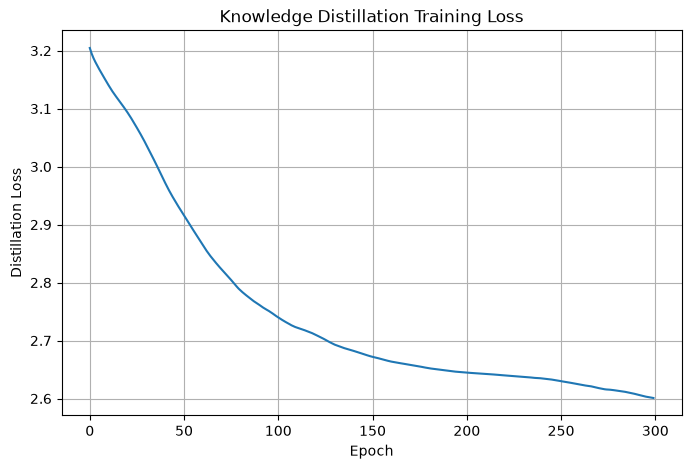

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    student_loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Distillation Loss")

plt.title(
    "Knowledge Distillation Training Loss"
)

plt.grid(True)

plt.show()

## Step 13: Compare Teacher and Student Predictions

We compare the predictions made by the teacher and student models.

In [14]:
print("First 20 Teacher Predictions:")
print(teacher_predictions[:20])

print("\nFirst 20 Student Predictions:")
print(student_predictions[:20])

print("\nActual Labels:")
print(y[:20])

First 20 Teacher Predictions:
tensor([0, 1, 1, 0, 0, 1, 0, 2, 2, 1, 2, 2, 1, 1, 2, 0, 1, 1, 2, 1])

First 20 Student Predictions:
tensor([0, 1, 1, 0, 0, 0, 0, 1, 2, 1, 1, 2, 2, 1, 2, 0, 1, 1, 1, 0])

Actual Labels:
tensor([0, 1, 1, 0, 0, 1, 0, 2, 2, 1, 2, 2, 1, 1, 2, 0, 1, 1, 2, 1])


## Step 14: Teacher-Student Agreement

We calculate how often the student makes the same prediction as the
teacher.

In [15]:
agreement = (
    teacher_predictions
    == student_predictions
).float().mean()

print(
    "Teacher-Student Agreement:",
    round(
        agreement.item() * 100,
        2
    ),
    "%"
)

Teacher-Student Agreement: 53.2 %


## Step 15: Results

The Knowledge Distillation experiment demonstrates:

- A larger teacher model
- A smaller student model
- Teacher training
- Soft probability distributions
- Temperature scaling
- Distillation loss
- Student training
- Knowledge transfer
- Teacher-student prediction agreement

In [16]:
print("========== TASK 12 RESULTS ==========")

print(
    "Teacher Parameters:",
    teacher_parameters
)

print(
    "Student Parameters:",
    student_parameters
)

print(
    "Temperature:",
    temperature
)

print(
    "Teacher Accuracy:",
    round(
        teacher_accuracy.item() * 100,
        2
    ),
    "%"
)

print(
    "Student Accuracy:",
    round(
        student_accuracy.item() * 100,
        2
    ),
    "%"
)

print(
    "Teacher-Student Agreement:",
    round(
        agreement.item() * 100,
        2
    ),
    "%"
)

print("=====================================")

========== TASK 12 RESULTS ==========
Teacher Parameters: 5059
Student Parameters: 227
Temperature: 3.0
Teacher Accuracy: 100.0 %
Student Accuracy: 53.2 %
Teacher-Student Agreement: 53.2 %


# Conclusion

A simplified Knowledge Distillation system was implemented.

A larger teacher model was first trained on the dataset. A smaller
student model was then trained using both the original labels and the
soft predictions produced by the teacher.

The experiment demonstrates how knowledge from a larger model can be
transferred to a smaller model.

Knowledge distillation is useful for creating smaller and more efficient
models that require fewer computational resources while maintaining
useful performance.